Build a model to decide the species of the iris flower when all the details are provided 

In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("Iris.csv")


In [3]:
df.head()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [4]:
df["Species"].value_counts()

Species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

In [9]:
df.isnull().sum()

Sepal_Length    0
Sepal_Width     0
Petal_Length    0
Petal_Width     0
Species         0
dtype: int64

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


{'whiskers': [<matplotlib.lines.Line2D at 0x2b43e601090>,
 'caps': [<matplotlib.lines.Line2D at 0x2b43e601310>,
 'boxes': [<matplotlib.lines.Line2D at 0x2b43ea40f50>],
 'medians': [<matplotlib.lines.Line2D at 0x2b43e601590>],
 'fliers': [<matplotlib.lines.Line2D at 0x2b43e6016d0>],
 'means': []}

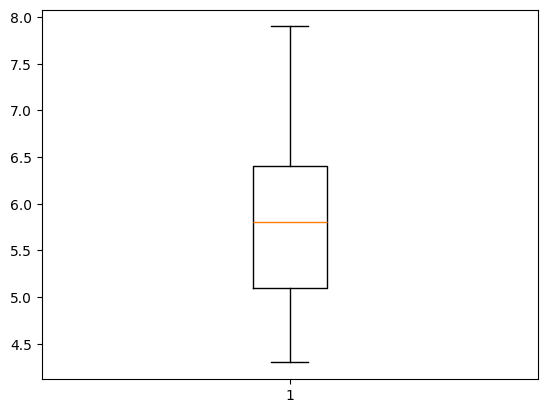

In [12]:
plt.boxplot(df["Sepal_Length"])

{'whiskers': [<matplotlib.lines.Line2D at 0x2b43e6b2d50>,
 'caps': [<matplotlib.lines.Line2D at 0x2b43e6b2fd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2b43e6b2c10>],
 'medians': [<matplotlib.lines.Line2D at 0x2b43e6b3250>],
 'fliers': [<matplotlib.lines.Line2D at 0x2b43e6b3390>],
 'means': []}

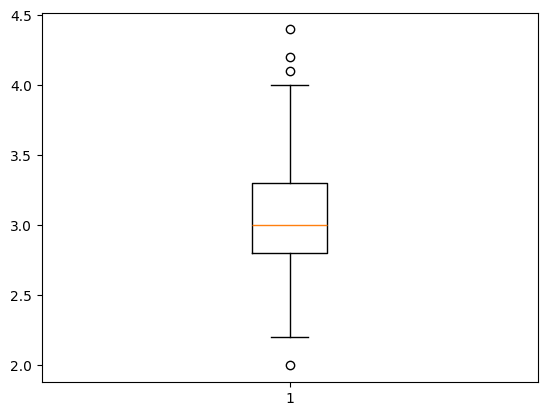

In [13]:
plt.boxplot(df["Sepal_Width"])

{'whiskers': [<matplotlib.lines.Line2D at 0x2b43e776850>,
 'caps': [<matplotlib.lines.Line2D at 0x2b43e776ad0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2b43e776710>],
 'medians': [<matplotlib.lines.Line2D at 0x2b43e776d50>],
 'fliers': [<matplotlib.lines.Line2D at 0x2b43e776e90>],
 'means': []}

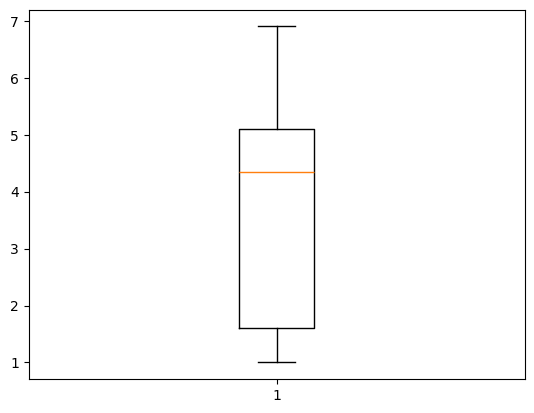

In [14]:
plt.boxplot(df["Petal_Length"])

{'whiskers': [<matplotlib.lines.Line2D at 0x2b43ef96350>,
 'caps': [<matplotlib.lines.Line2D at 0x2b43ef965d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2b43ef96210>],
 'medians': [<matplotlib.lines.Line2D at 0x2b43ef96850>],
 'fliers': [<matplotlib.lines.Line2D at 0x2b43ef96990>],
 'means': []}

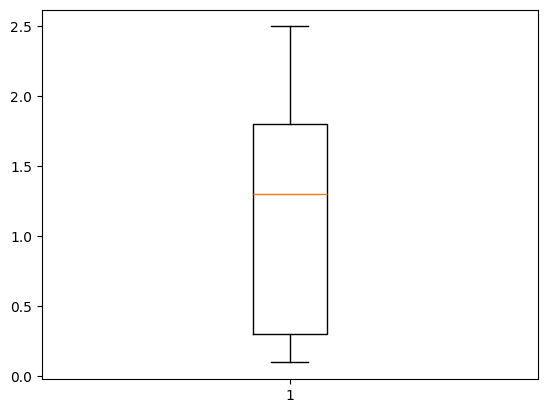

In [15]:
plt.boxplot(df["Petal_Width"])

In [17]:
mean = df["Sepal_Width"].mean()
std = df["Sepal_Width"].std()

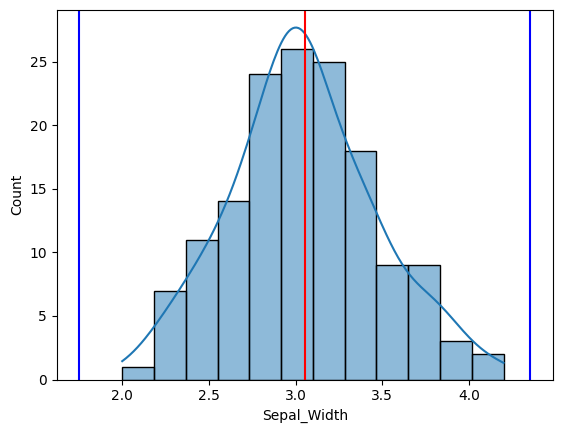

In [32]:
sns.histplot(data=df , x="Sepal_Width" , kde=True)
plt.axvline(mean , color ="red")
plt.axvline(mean+3*std , color = "blue")
plt.axvline(mean-3*std , color ="blue")

In [27]:
df[df["Sepal_Width"] > mean+3*std ]

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
15,5.7,4.4,1.5,0.4,Setosa


In [28]:
mean+3*std 

np.float64(4.354782934086521)

In [31]:
df.drop(df[df["Sepal_Width"] > mean+3*std ].index , inplace= True )

In [ ]:
# here no balancing of data required 
# no scaling reauired 


In [35]:
x = df.drop("Species" , axis = 1)
y=df["Species"]


In [36]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size= 0.2 ,random_state=30)

In [ ]:
# decide best parameters using gridSearchCHCV
# then build model using best parameter


In [37]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()
dtree.fit(x_train , y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [38]:
from sklearn.model_selection import cross_validate
result = cross_validate(dtree , x_train , y_train)
result

{'fit_time': array([0.00910783, 0.01021719, 0.00747252, 0.00562644, 0.00835443]),
 'score_time': array([0.0058279 , 0.00441384, 0.00407147, 0.00837946, 0.00791121]),
 'test_score': array([0.95833333, 0.91666667, 0.91666667, 0.95833333, 1.        ])}

In [39]:
print("validation_score : " ,result["test_score"].mean())

validation_score :  0.95


In [40]:
test_pred = dtree.predict(x_test)

In [53]:
train_pred = dtree.predict(x_train)

In [50]:
from sklearn.metrics import confusion_matrix , accuracy_score
con_m=confusion_matrix(y_test , test_pred)

In [59]:
con_m

array([[10,  0,  0],
       [ 0,  7,  0],
       [ 0,  2, 11]])

In [52]:
accuracy_score(y_test , test_pred)

0.9333333333333333

In [54]:
accuracy_score(y_train , train_pred)

1.0

In [60]:
import pandas as pd

labels = ["Setosa", "Versicolor", "Virginica"]

df = pd.DataFrame(con_m, columns=labels, index=labels)
print(df)

            Setosa  Versicolor  Virginica
Setosa          10           0          0
Versicolor       0           7          0
Virginica        0           2         11


In [55]:
from sklearn.tree import plot_tree

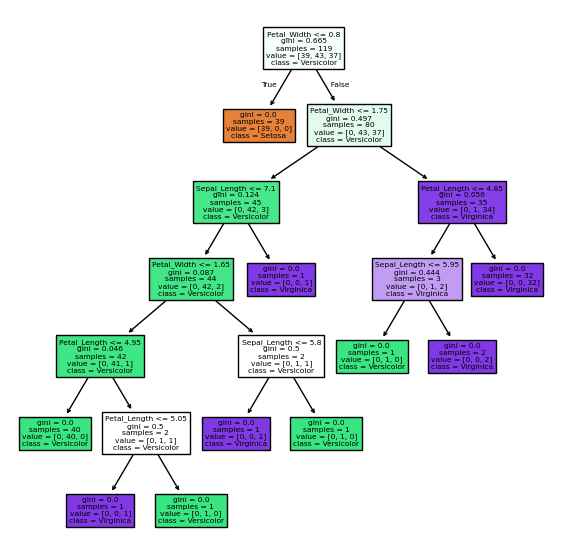

In [58]:
plt.figure(figsize=(7,7))
plot_tree(dtree ,class_names= df["Species"].unique(),feature_names = x.columns , filled =True)
plt.show()
